In [1]:
# Baseline Models: Random Generator + Markov Chain
import sys
sys.path.append("../src")

import numpy as np
from pathlib import Path
import random
import pretty_midi

from evaluation.baselines import generate_random_midi, MarkovChainModel
from evaluation.metrics import evaluate_folder, evaluate_midi_file, load_midi_notes

random.seed(42)
np.random.seed(42)

# Output directories
random_dir = Path("../outputs/generated_midis/baseline_random")
markov_dir = Path("../outputs/generated_midis/baseline_markov")
random_dir.mkdir(parents=True, exist_ok=True)
markov_dir.mkdir(parents=True, exist_ok=True)

print("Output directories created.")


Output directories created.


In [2]:
# Baseline 1: Random Note Generator
print("Generating 10 random MIDI files...")
for i in range(10):
    out_path = random_dir / f"random_generated_{i+1}.mid"
    generate_random_midi(
        output_path=out_path,
        num_notes=80,
        duration=8.0,
        pitch_range=(48, 84)
    )
    print(f"  Saved: {out_path}")

print("Random baseline generation complete.")


Generating 10 random MIDI files...
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_1.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_2.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_3.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_4.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_5.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_6.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_7.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_8.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_9.mid
  Saved: ..\outputs\generated_midis\baseline_random\random_generated_10.mid
Random baseline generation complete.


In [3]:
# Baseline 2: Markov Chain - Train on MAESTRO
from pathlib import Path
import pandas as pd

maestro_root = Path("../data/raw_midi/maestro-v3.0.0")
df = pd.read_csv(maestro_root / "maestro-v3.0.0.csv")
train_files = [maestro_root / row["midi_filename"] for _, row in df[df["split"] == "train"].iterrows()]

print(f"Training Markov model on {len(train_files)} files (using first 200)...")
markov = MarkovChainModel(order=2)
markov.fit(train_files, max_files=200)


Training Markov model on 962 files (using first 200)...


Markov model trained on 200 files.
  Pitch states: 6725
  Duration states: 2300


In [4]:
# Generate 10 Markov Chain compositions
print("Generating 10 Markov Chain MIDI files...")
for i in range(10):
    out_path = markov_dir / f"markov_generated_{i+1}.mid"
    markov.generate(out_path, num_notes=120)
    print(f"  Saved: {out_path}")

print("Markov baseline generation complete.")


Generating 10 Markov Chain MIDI files...
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_1.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_2.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_3.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_4.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_5.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_6.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_7.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_8.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_9.mid
  Saved: ..\outputs\generated_midis\baseline_markov\markov_generated_10.mid
Markov baseline generation complete.


In [5]:
# Evaluate all models using project spec metrics
import sys
sys.path.append("../src")
from evaluation.metrics import evaluate_folder, load_midi_notes
import numpy as np

# Build reference notes from test set MAESTRO files
import pretty_midi, pandas as pd
from pathlib import Path

maestro_root = Path("../data/raw_midi/maestro-v3.0.0")
df = pd.read_csv(maestro_root / "maestro-v3.0.0.csv")
test_files = [maestro_root / row["midi_filename"] for _, row in df[df["split"] == "test"].iterrows()][:20]

ref_notes = []
for f in test_files:
    try:
        midi = pretty_midi.PrettyMIDI(str(f))
        for inst in midi.instruments:
            if not inst.is_drum:
                for n in inst.notes:
                    ref_notes.append((n.pitch, round(n.end - n.start, 2)))
    except:
        pass
print(f"Reference notes loaded: {len(ref_notes)}")


Reference notes loaded: 58667


In [6]:
# Run evaluation on all model outputs
from evaluation.metrics import evaluate_folder

models = {
    "Random Generator":   "../outputs/generated_midis/baseline_random",
    "Markov Chain":       "../outputs/generated_midis/baseline_markov",
    "Task 1: Autoencoder":"../outputs/generated_midis/task1_autoencoder",
    "Task 2: VAE":        "../outputs/generated_midis/task2_vae",
    "Task 3: Transformer":"../outputs/generated_midis/task3_transformer",
}

results = {}
for model_name, folder in models.items():
    r = evaluate_folder(folder, reference_notes=ref_notes)
    results[model_name] = r
    print(f"{model_name}:")
    for k, v in r.items():
        print(f"  {k}: {v:.4f}")
    print()


Random Generator:
  num_notes: 80.0000
  rhythm_diversity: 0.2038
  repetition_ratio: 0.0013
  pitch_histogram_similarity: 0.3779



Markov Chain:
  num_notes: 120.0000
  rhythm_diversity: 0.0733
  repetition_ratio: 0.0009
  pitch_histogram_similarity: 0.3289



Task 1: Autoencoder:
  num_notes: 40.2000
  rhythm_diversity: 0.4537
  repetition_ratio: 0.0186
  pitch_histogram_similarity: 0.4808



Task 2: VAE:
  num_notes: 67.8571
  rhythm_diversity: 0.0830
  repetition_ratio: 0.0136
  pitch_histogram_similarity: 0.3550



Task 3: Transformer:
  num_notes: 266.8000
  rhythm_diversity: 0.0824
  repetition_ratio: 0.0378
  pitch_histogram_similarity: 0.5355



In [7]:
# Print comparison table (matches project spec Table 3 format)
print("=" * 85)
print(f"{'Model':<28} {'Num Notes':>10} {'Rhythm Div':>12} {'Repetition':>12} {'Pitch Sim':>12}")
print("=" * 85)

for model_name, r in results.items():
    nn   = f"{r.get('num_notes', 0):.1f}"
    rd   = f"{r.get('rhythm_diversity', 0):.4f}"
    rep  = f"{r.get('repetition_ratio', 0):.4f}"
    ph   = f"{r.get('pitch_histogram_similarity', 0):.4f}" if 'pitch_histogram_similarity' in r else "  N/A"
    print(f"{model_name:<28} {nn:>10} {rd:>12} {rep:>12} {ph:>12}")

print("=" * 85)
print()
print("Metric Guide:")
print("  Rhythm Diversity  -> Higher is better (more rhythmic variety)")
print("  Repetition Ratio  -> Lower is better (less repetitive)")
print("  Pitch Similarity  -> Lower is better (closer to real music distribution)")


Model                         Num Notes   Rhythm Div   Repetition    Pitch Sim
Random Generator                   80.0       0.2038       0.0013       0.3779
Markov Chain                      120.0       0.0733       0.0009       0.3289
Task 1: Autoencoder                40.2       0.4537       0.0186       0.4808
Task 2: VAE                        67.9       0.0830       0.0136       0.3550
Task 3: Transformer               266.8       0.0824       0.0378       0.5355

Metric Guide:
  Rhythm Diversity  -> Higher is better (more rhythmic variety)
  Repetition Ratio  -> Lower is better (less repetitive)
  Pitch Similarity  -> Lower is better (closer to real music distribution)


In [8]:
# Save results to numpy for report
import json
with open("../outputs/plots/evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Results saved to outputs/plots/evaluation_results.json")


Results saved to outputs/plots/evaluation_results.json


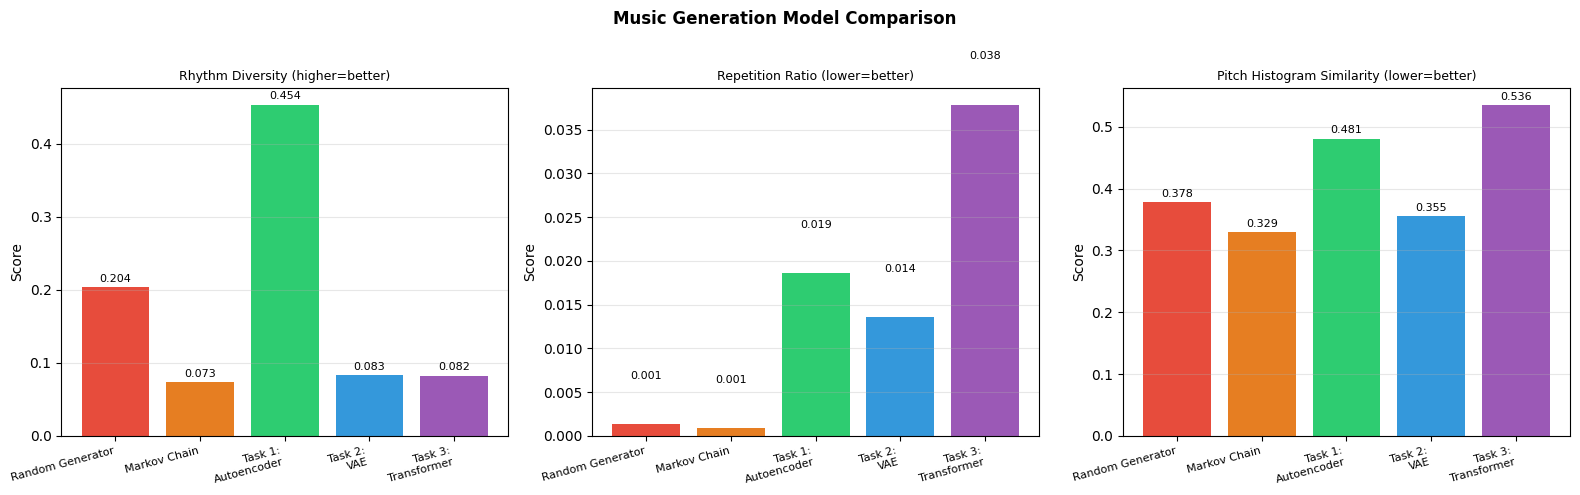

Comparison plot saved.


In [9]:
# Plot metric comparison bar charts
import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
metrics_to_plot = ["rhythm_diversity", "repetition_ratio", "pitch_histogram_similarity"]
metric_labels = ["Rhythm Diversity (higher=better)", "Repetition Ratio (lower=better)", "Pitch Histogram Similarity (lower=better)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    values = [results[m].get(metric, 0) for m in model_names]
    colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6"]
    bars = ax.bar(range(len(model_names)), values, color=colors)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(": ", ":\n") for m in model_names], rotation=15, ha="right", fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Music Generation Model Comparison", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/plots/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison plot saved.")
